In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

In [21]:
LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
    'Effusion', 'Emphysema', 'Fibrosis', 'Hernia',
    'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening',
    'Pneumonia', 'Pneumothorax'
]

In [25]:
def run_eda(metadata_path: str ='Data_Entry_2017.csv'):
    df = pd.read_csv(metadata_path)

    # --- 1. Class distribution ---
    label_counts = {lbl: 0 for lbl in LABELS}
    label_counts['No Finding'] = 0

    for findings in df['Finding Labels']:
        for f in findings.split('|'):
            if f in label_counts:
                label_counts[f] += 1

    counts_df = pd.DataFrame.from_dict(
        label_counts, orient='index', columns=['count']
    ).sort_values('count', ascending=False)

    print("=== Class Distribution ===")
    print(counts_df.to_string())
    print(f"\nTotal images: {len(df):,}")
    print(f"Max/Min ratio: {counts_df['count'].max() / counts_df['count'].min():.1f}x")

    # Bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    counts_df.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('NIH ChestX-ray14 — Class Distribution')
    ax.set_ylabel('Number of images')
    plt.tight_layout()
    plt.savefig('reports/class_distribution.png', dpi=150)

    # --- 2. Label co-occurrence matrix ---
    binary_matrix = np.zeros((len(df), len(LABELS)))
    for i, findings in enumerate(df['Finding Labels']):
        for lbl in findings.split('|'):
            if lbl in LABELS:
                binary_matrix[i, LABELS.index(lbl)] = 1

    cooccurrence = binary_matrix.T @ binary_matrix  # (14, 14)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        cooccurrence, xticklabels=LABELS, yticklabels=LABELS,
        annot=True, fmt='.0f', cmap='Blues', ax=ax
    )
    ax.set_title('Label Co-occurrence Matrix')
    plt.tight_layout()
    plt.savefig('reports/cooccurrence_matrix.png', dpi=150)

    # --- 3. Pixel statistics (sample 1000 images) ---
    return df, binary_matrix

=== Class Distribution ===
                    count
No Finding          60361
Infiltration        19894
Effusion            13317
Atelectasis         11559
Nodule               6331
Mass                 5782
Pneumothorax         5302
Consolidation        4667
Pleural_Thickening   3385
Cardiomegaly         2776
Emphysema            2516
Edema                2303
Fibrosis             1686
Pneumonia            1431
Hernia                227

Total images: 112,120
Max/Min ratio: 265.9x


(             Image Index          Finding Labels  Follow-up #  Patient ID  \
 0       00000001_000.png            Cardiomegaly            0           1   
 1       00000001_001.png  Cardiomegaly|Emphysema            1           1   
 2       00000001_002.png   Cardiomegaly|Effusion            2           1   
 3       00000002_000.png              No Finding            0           2   
 4       00000003_000.png                  Hernia            0           3   
 ...                  ...                     ...          ...         ...   
 112115  00030801_001.png          Mass|Pneumonia            1       30801   
 112116  00030802_000.png              No Finding            0       30802   
 112117  00030803_000.png              No Finding            0       30803   
 112118  00030804_000.png              No Finding            0       30804   
 112119  00030805_000.png              No Finding            0       30805   
 
         Patient Age Patient Gender View Position  OriginalIma

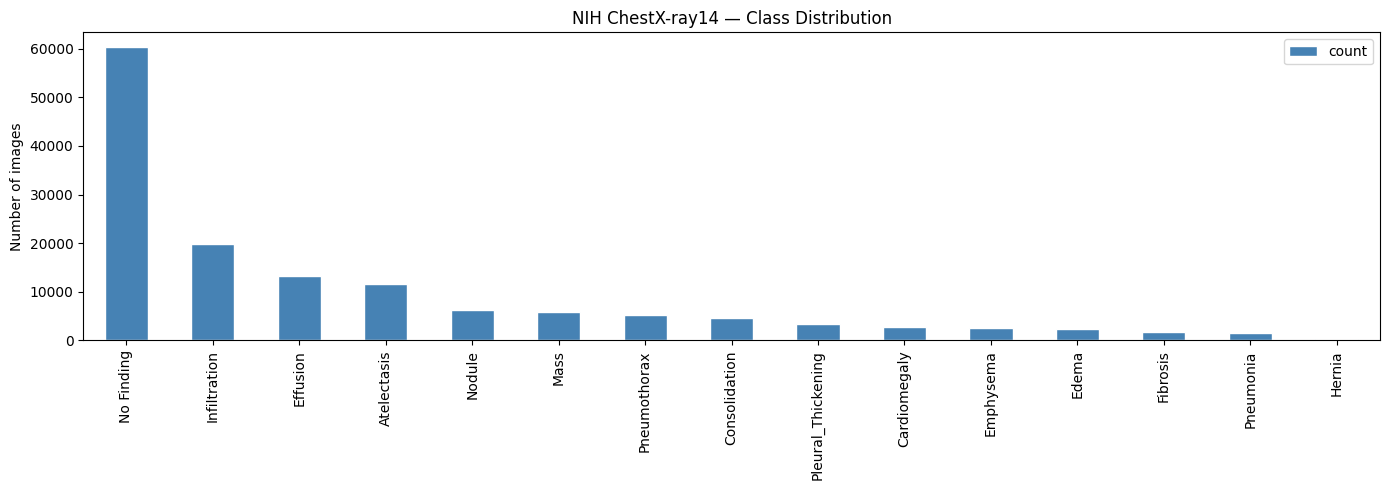

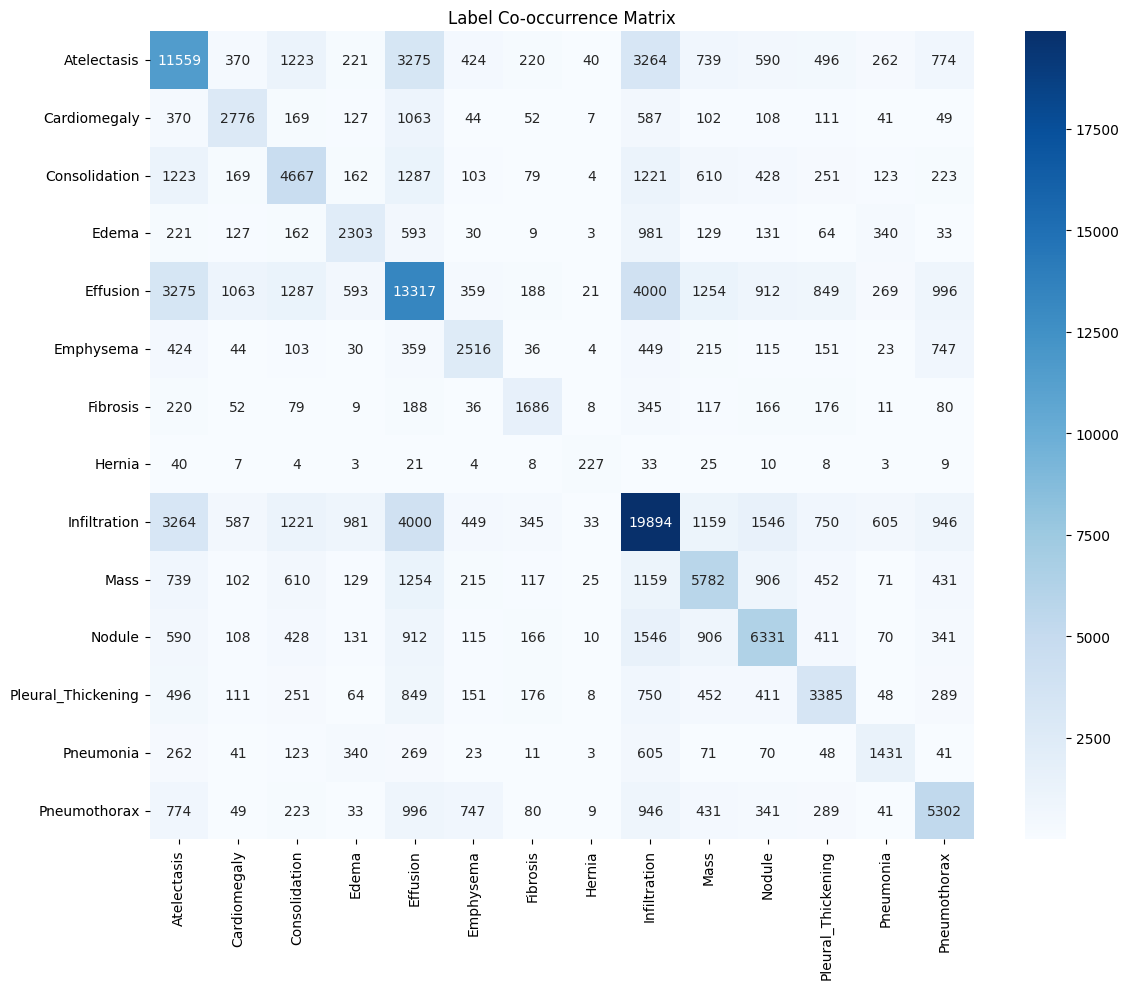

In [28]:
import os
os.makedirs('reports', exist_ok=True)
run_eda('Data_Entry_2017.csv')